# Model Comparison: VGG16, VGG19, DenseNet121, ResNet50, MobileNet, InceptionV3

This notebook compares the performance of 6 different deep learning models on the leaf classification task.


In [5]:
# Import libraries
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# Configure GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"[OK] GPU memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(e)


[OK] GPU memory growth enabled for 1 GPU(s)


In [6]:
# Load test dataset
print("Loading test dataset...")
test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

test_set = test_datagen.flow_from_directory(
    'removed background',
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

class_names = list(test_set.class_indices.keys())
print(f"\nTest set loaded: {test_set.samples} images belonging to {len(class_names)} classes")


Loading test dataset...
Found 1046 images belonging to 20 classes.

Test set loaded: 1046 images belonging to 20 classes


In [7]:
# Load all 6 models
print("Loading models...")

models = {}
model_names = ['VGG16', 'VGG19', 'DenseNet121', 'ResNet50', 'MobileNet', 'InceptionV3']
model_files = {
    'VGG16': 'VGG16_best_model.keras',
    'VGG19': 'VGG19_best_model.keras',
    'DenseNet121': 'DenseNet121_best_model.keras',
    'ResNet50': 'ResNet50_best_model.keras',
    'MobileNet': 'MobileNet_best_model.keras',
    'InceptionV3': 'InceptionV3_best_model.keras'
}

for name in model_names:
    try:
        models[name] = load_model(model_files[name])
        print(f"✓ {name} loaded successfully")
    except Exception as e:
        print(f"✗ Failed to load {name}: {e}")

print(f"\nTotal models loaded: {len(models)}")


Loading models...
✓ VGG16 loaded successfully
✓ VGG19 loaded successfully
✓ DenseNet121 loaded successfully
✓ ResNet50 loaded successfully
✓ MobileNet loaded successfully
✓ InceptionV3 loaded successfully

Total models loaded: 6


In [8]:
# Evaluate each model on test set
print("Evaluating models on test set...")
print("=" * 60)

results = {}

# Create separate test set for InceptionV3 (requires 299x299 input)
test_datagen_299 = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_set_299 = test_datagen_299.flow_from_directory(
    'removed background',
    target_size=(299, 299),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

for name, model in models.items():
    try:
        print(f"\nEvaluating {name}...")
        
        # Use appropriate test set based on model input size
        if name == 'InceptionV3':
            current_test_set = test_set_299
        else:
            current_test_set = test_set
        
        # Reset test set before predictions
        current_test_set.reset()
        
        # Get predictions
        y_pred_probs = model.predict(current_test_set, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)
        
        # Get true labels - handle both numpy arrays and tensors
        current_test_set.reset()
        true_categories_list = []
        for x, y in current_test_set:
            # Convert to numpy if it's a tensor, otherwise use as is
            if hasattr(y, 'numpy'):
                y_np = y.numpy()
            else:
                y_np = np.array(y)
            true_categories_list.append(y_np)
            if len(true_categories_list) * current_test_set.batch_size >= current_test_set.samples:
                break
        true_categories = np.concatenate(true_categories_list, axis=0)
        y_true = np.argmax(true_categories, axis=1)
        
        # Calculate accuracy
        accuracy = accuracy_score(y_true, y_pred)
        
        # Store results
        results[name] = {
            'accuracy': accuracy,
            'y_true': y_true,
            'y_pred': y_pred,
            'classification_report': classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
        }
        
        print(f"{name} Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    except Exception as e:
        print(f"✗ Error evaluating {name}: {e}")
        import traceback
        traceback.print_exc()

print("\n" + "=" * 60)


Evaluating models on test set...
Found 1046 images belonging to 20 classes.

Evaluating VGG16...
VGG16 Accuracy: 0.7285 (72.85%)

Evaluating VGG19...
VGG19 Accuracy: 0.7132 (71.32%)

Evaluating DenseNet121...
DenseNet121 Accuracy: 0.8270 (82.70%)

Evaluating ResNet50...
ResNet50 Accuracy: 0.2620 (26.20%)

Evaluating MobileNet...
MobileNet Accuracy: 0.8767 (87.67%)

Evaluating InceptionV3...
InceptionV3 Accuracy: 0.8547 (85.47%)



In [9]:
# Create comparison table
print("\nModel Comparison Summary")
print("=" * 60)

comparison_data = []
for name, result in results.items():
    report = result['classification_report']
    comparison_data.append({
        'Model': name,
        'Accuracy': f"{result['accuracy']:.4f} ({result['accuracy']*100:.2f}%)",
        'Macro Avg Precision': f"{report['macro avg']['precision']:.4f}",
        'Macro Avg Recall': f"{report['macro avg']['recall']:.4f}",
        'Macro Avg F1-Score': f"{report['macro avg']['f1-score']:.4f}"
    })

df = pd.DataFrame(comparison_data)
print(df.to_string(index=False))



Model Comparison Summary
      Model        Accuracy Macro Avg Precision Macro Avg Recall Macro Avg F1-Score
      VGG16 0.7285 (72.85%)              0.7425           0.7348             0.7249
      VGG19 0.7132 (71.32%)              0.7200           0.7143             0.7060
DenseNet121 0.8270 (82.70%)              0.8308           0.8368             0.8232
   ResNet50 0.2620 (26.20%)              0.1814           0.2568             0.1921
  MobileNet 0.8767 (87.67%)              0.8914           0.8817             0.8763
InceptionV3 0.8547 (85.47%)              0.8657           0.8626             0.8560


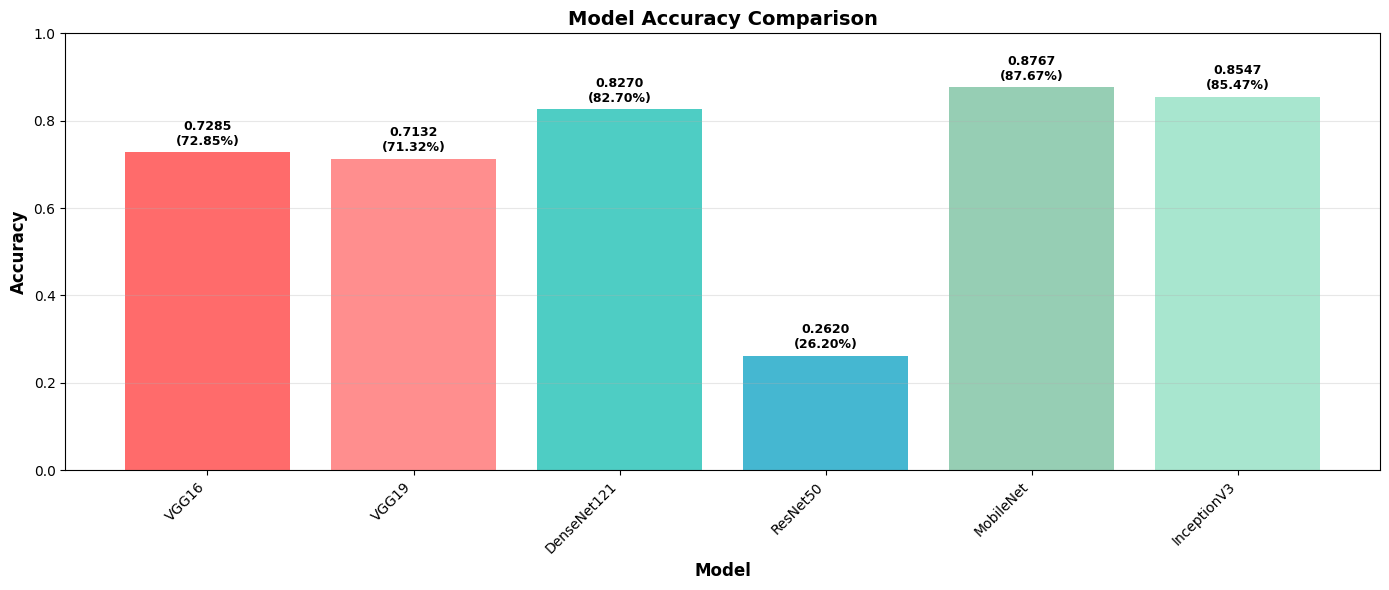

In [10]:
# Visualize accuracy comparison
plt.figure(figsize=(14, 6))
model_names_list = list(results.keys())
accuracies = [results[name]['accuracy'] for name in model_names_list]

bars = plt.bar(model_names_list, accuracies, color=['#FF6B6B', '#FF8E8E', '#4ECDC4', '#45B7D1', '#96CEB4', '#A8E6CF'])
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')

# Add accuracy values on top of bars
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.4f}\n({acc*100:.2f}%)', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


In [11]:
# Detailed classification report for each model
for name, result in results.items():
    print(f"\n{'='*60}")
    print(f"{name} - Detailed Classification Report")
    print(f"{'='*60}")
    print(classification_report(result['y_true'], result['y_pred'], target_names=class_names, zero_division=0))



VGG16 - Detailed Classification Report
                precision    recall  f1-score   support

      Aloevera       0.86      0.80      0.83        60
          Amla       0.38      0.20      0.26        40
        Bamboo       0.88      0.83      0.85        52
        Bhrami       0.93      0.81      0.86        62
    Bringaraja       0.79      0.65      0.71        40
        Castor       0.86      0.90      0.88        63
        Coffee       0.56      1.00      0.72        45
     Coriender       1.00      0.77      0.87        57
         Curry       0.86      0.38      0.52        64
    Eucalyptus       0.95      0.86      0.90        42
        Ginger       0.79      0.95      0.86        40
         Guava       0.48      0.65      0.55        62
         Henna       0.66      0.69      0.67        45
      Hibiscus       0.25      0.24      0.25        58
         Lemon       0.67      0.64      0.65        55
          Mint       0.67      0.61      0.64        69
       

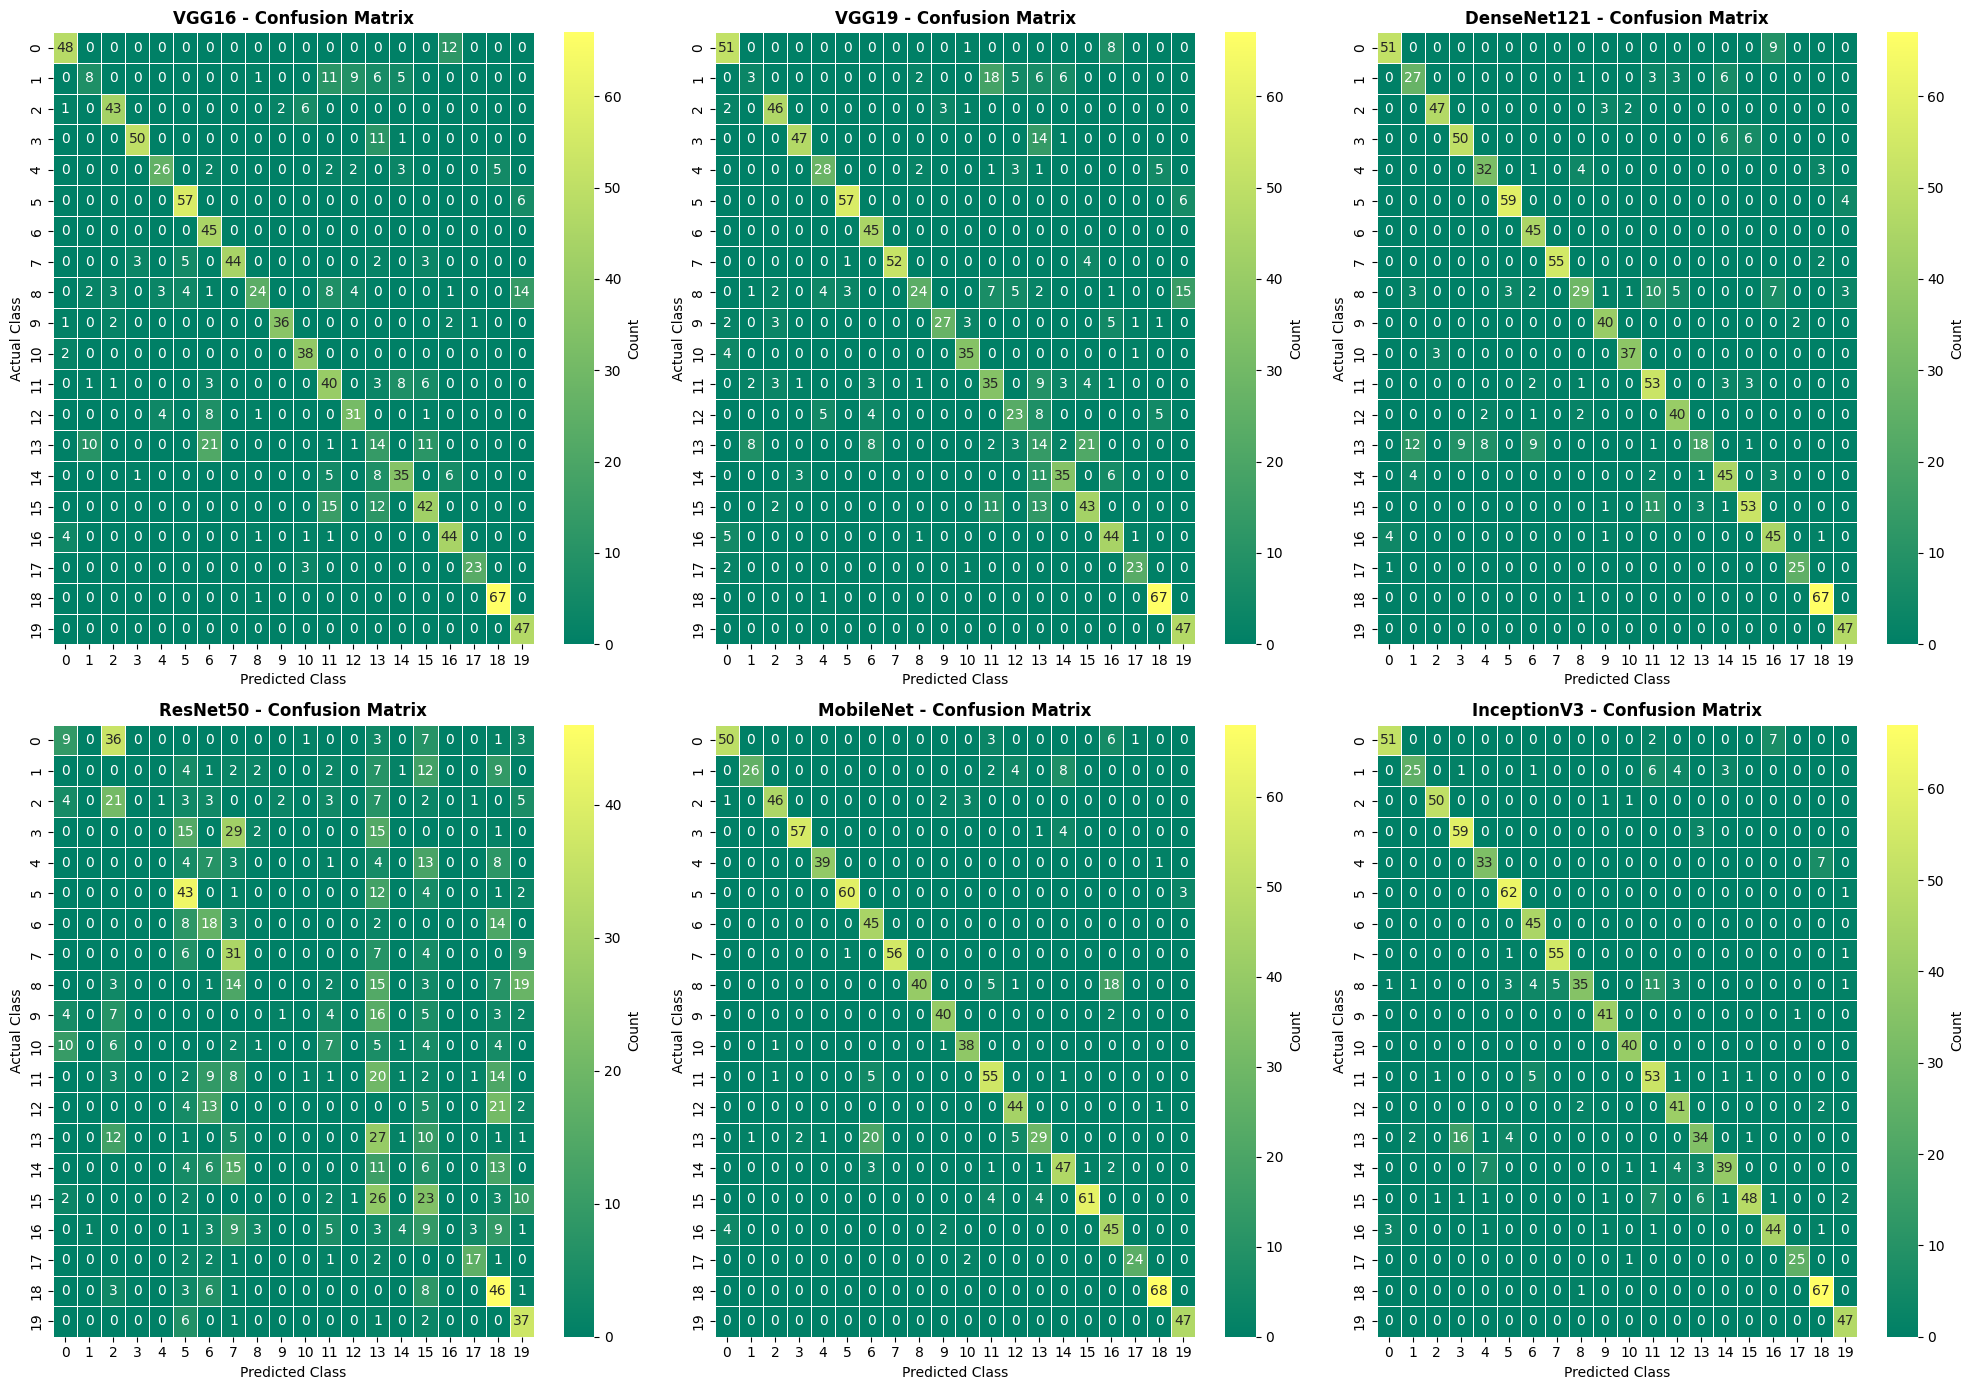

In [12]:
# Confusion matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.ravel()

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(result['y_true'], result['y_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='summer', ax=axes[idx], 
                cbar_kws={'label': 'Count'}, linewidths=0.5)
    axes[idx].set_title(f'{name} - Confusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Class', fontsize=10)
    axes[idx].set_ylabel('Actual Class', fontsize=10)

plt.tight_layout()
plt.show()


In [13]:
# Save results to CSV
model_names_list = list(results.keys())
accuracies = [results[name]['accuracy'] for name in model_names_list]

results_df = pd.DataFrame({
    'Model': model_names_list,
    'Accuracy': accuracies
})
results_df.to_csv('model_comparison_results.csv', index=False)
print("Results saved to 'model_comparison_results.csv'")


Results saved to 'model_comparison_results.csv'
